(17996, 17)
             Artist Name                             Track Name  Popularity  \
0             Bruno Mars  That's What I Like (feat. Gucci Mane)        60.0   
1                 Boston                           Hitch a Ride        54.0   
2          The Raincoats                     No Side to Fall In        35.0   
3                   Deno             Lingo (feat. J.I & Chunkz)        66.0   
4  Red Hot Chili Peppers      Nobody Weird Like Me - Remastered        53.0   

   danceability  energy   key  loudness  mode  speechiness  acousticness  \
0         0.854   0.564   1.0    -4.964     1       0.0485      0.017100   
1         0.382   0.814   3.0    -7.230     1       0.0406      0.001100   
2         0.434   0.614   6.0    -8.334     1       0.0525      0.486000   
3         0.853   0.597  10.0    -6.528     0       0.0555      0.021200   
4         0.167   0.975   2.0    -4.279     1       0.2160      0.000169   

   instrumentalness  liveness  valence    tempo  duratio

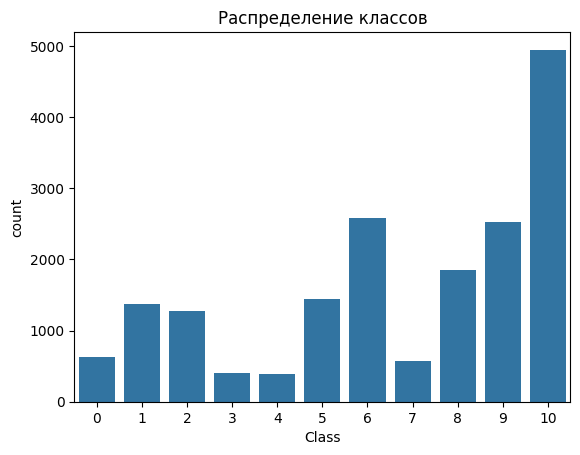

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
sns.countplot(x="Class", data=df)
plt.title("Распределение классов")
plt.show()

Popularity            0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
duration_in min/ms    0
time_signature        0
Class                 0
dtype: int64
Class
10    4949
6     2587
9     2524
8     1854
5     1447
1     1373
2     1272
0      625
7      576
3      402
4      387
Name: count, dtype: int64


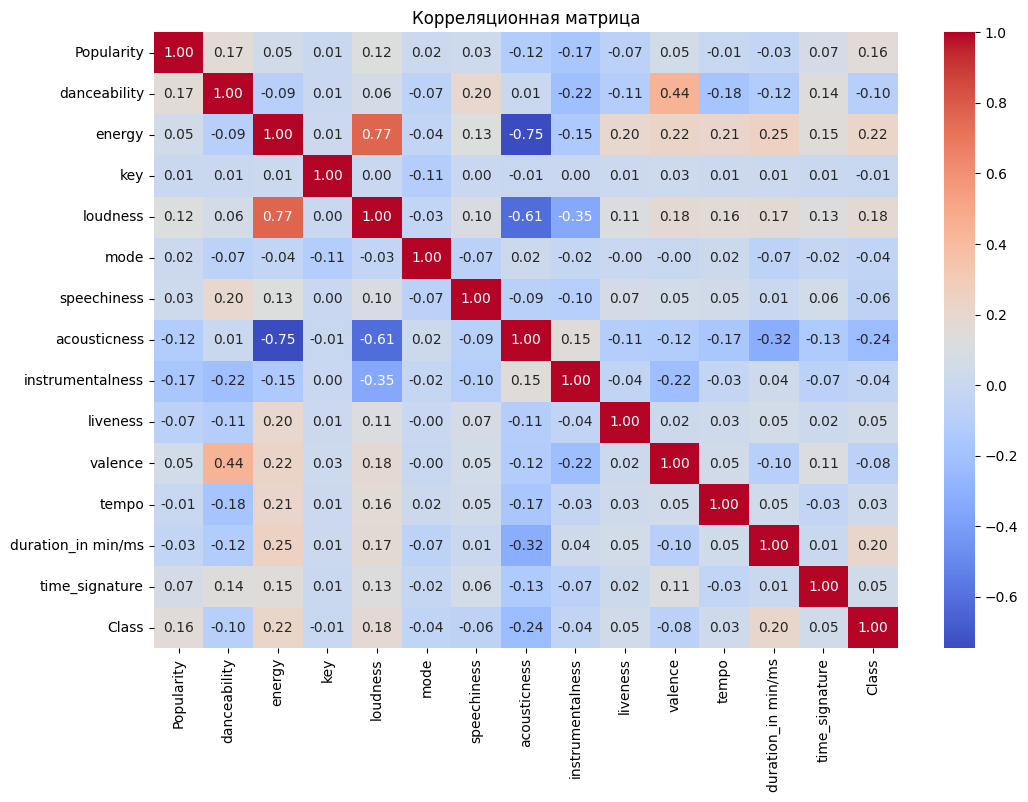

In [2]:
# удаляем столбцы
df = df.drop(columns=["Artist Name", "Track Name"])
# избавляемся от пропусков
df = df.fillna(df.median(numeric_only=True))
print(df.isnull().sum())
print(df["Class"].value_counts())
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

In [24]:
# X — признаки (всё кроме целевого столбца)
X = df.drop(columns=["Class"])
# y — целевая переменная (то что предсказываем)
y = df["Class"]
print(X.shape)
print(y.shape)

(17996, 14)
(17996,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape}")
print(f"Test: {X_test.shape}")

Train : (14396, 14)
Test: (3600, 14)


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1 Дерево решений
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# 2 Случайный лес
rf = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 3 Градиентный бустинг
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print(f"Дерево решений:    {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Случайный лес:     {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Градиентный бустинг: {accuracy_score(y_test, y_pred_gb):.4f}")

Дерево решений:    0.3606
Случайный лес:     0.4994
Градиентный бустинг: 0.5372
